# Protein–Ligand Interaction Profiling (PLIP)

Visualizations showcasing GUILD's interaction analysis capabilities.  
Data source: `plip_interactions.tsv` — 98,538 docked poses across 106 proteins and ~1,000 ligands.

In [ ]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Publication defaults ──────────────────────────────────────────────────────
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.titleweight": "bold",
    "axes.labelsize": 7,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "legend.fontsize": 6.5,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 150,
})

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = Path("plip_interactions_top25.tsv")
OUT_DIR   = Path("plip_figures")
OUT_DIR.mkdir(exist_ok=True)

print("Ready ✓")

Ready ✓


In [4]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, sep="\t")
df["pdb_id"] = df["protein_config_id"].str.split("-").str[0]

# ── Exclude proteins ─────────────────────────────────────────────────────────
EXCLUDE_PROTEINS = {"7v6a", "8fx5", "8wrz", "8wu1", "8dzs"}
df = df[~df["pdb_id"].isin(EXCLUDE_PROTEINS)].copy()

INT_COLS = ["n_hbonds", "n_hydrophobic", "n_pistacking", "n_pication",
            "n_saltbridges", "n_halogen"]
INT_LABELS = ["H-bonds", "Hydrophobic", "π-stacking", "π-cation",
              "Salt bridges", "Halogen"]

# Pick a well-populated example protein for single-protein figures
EXAMPLE_PDB = "6u1n"
df_ex = df[df["pdb_id"] == EXAMPLE_PDB].copy()

print(f"Full dataset (after excluding {EXCLUDE_PROTEINS}): {len(df):,} rows, {df['pdb_id'].nunique()} proteins, {df['smiles'].nunique()} ligands")
print(f"Example protein {EXAMPLE_PDB}: {len(df_ex):,} poses")

Full dataset (after excluding {'8fx5', '8wrz', '8wu1', '8dzs', '7v6a'}): 23,959 rows, 25 proteins, 1001 ligands
Example protein 6u1n: 1,931 poses


---
## Interaction profile stacked bar chart (top 25)

Each row is a protein, each coloured segment an interaction type.  
Bar lengths show **raw mean counts** (no normalisation).  
A thin gap separates each interaction segment for readability.

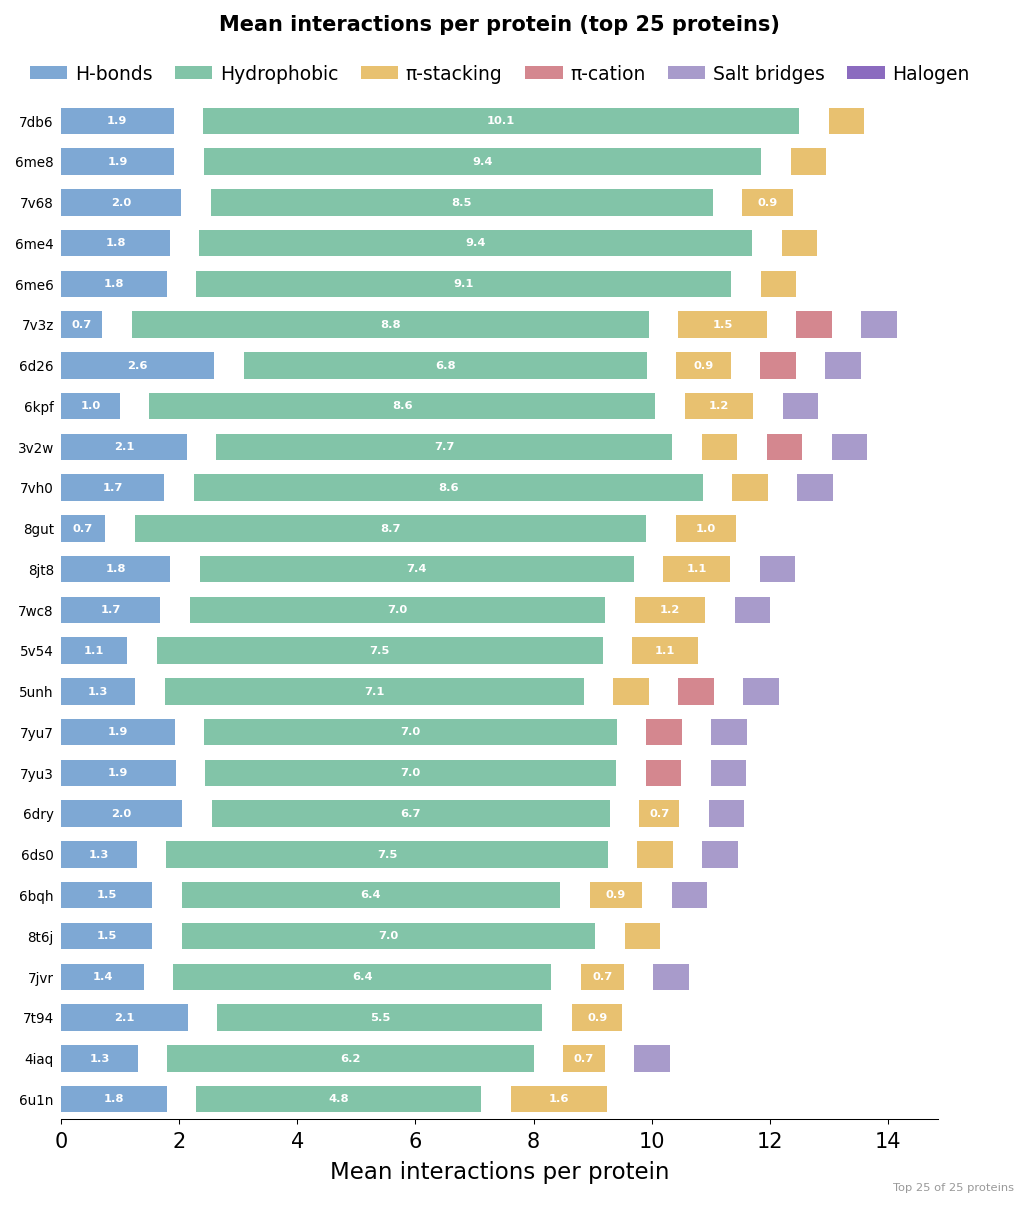

Saved stacked bar chart


In [8]:
# ── Interaction profile stacked bar chart (top 25) ─────────────────────────────

COL_COLORS = {
    "H-bonds":      "#7EA8D4",
    "Hydrophobic":  "#82C4A8",
    "π-stacking":   "#E8C170",
    "π-cation":     "#D4878F",
    "Salt bridges": "#A89BCB",
    "Halogen":      "#8B6BBF",
}

protein_means = df.groupby("pdb_id")[INT_COLS].mean()
protein_means.columns = INT_LABELS

# Sort by total, keep top 25
protein_means["total"] = protein_means.sum(axis=1)
protein_means = protein_means.sort_values("total", ascending=False)
top25 = protein_means.head(25).drop(columns="total")

# Reverse so the largest bar is on top
top25 = top25.iloc[::-1]

GAP = 0.5        # gap (in data units) between segments
MIN_WIDTH = 0.6   # minimum display width for tiny segments
DROP_THRESH = 0.05  # drop values below this threshold

fig, ax = plt.subplots(figsize=(7.0, 8.0))

y_pos = np.arange(len(top25))

for i, row_label in enumerate(top25.index):
    left = 0.0
    first = True
    for _j, col in enumerate(top25.columns):
        val = top25.loc[row_label, col]
        if val < DROP_THRESH:
            continue
        color = COL_COLORS[col]
        if not first:
            left += GAP
        first = False
        display_width = max(val, MIN_WIDTH)
        ax.barh(y_pos[i], display_width, left=left, height=0.65,
                color=color, edgecolor="none", linewidth=0,
                zorder=2)
        if val > 0.6:
            ax.text(left + display_width / 2, y_pos[i],
                    f"{val:.1f}", ha="center", va="center",
                    fontsize=5.5, color="white", fontweight="bold", zorder=3)
        left += display_width

# Add a bit of vertical room above top bar for the legend
ax.set_ylim(-0.5, len(top25) + 0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(top25.index, fontsize=6.5)
ax.set_xlabel("Mean interactions per protein", fontsize=11)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=2.5, labelsize=10)

for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_linewidth(0.5)

# Legend — inside axes, top-center
handles = [plt.Rectangle((0, 0), 1, 1, fc=COL_COLORS[c], ec="none")
           for c in top25.columns]
ax.legend(handles, top25.columns, loc="upper center", fontsize=9,
          ncol=6, frameon=False, handletextpad=0.4, columnspacing=1.2)

ax.set_title("Mean interactions per protein (top 25 proteins)",
             fontsize=10, fontweight="bold", pad=8)

fig.text(0.99, 0.005, f"Top 25 of {df['pdb_id'].nunique()} proteins",
         fontsize=5.5, color="#999", ha="right", va="bottom")

plt.tight_layout()
for ext in ("png", "pdf", "svg"):
    fig.savefig(OUT_DIR / f"plip_interaction_stacked.{ext}",
                dpi=600, bbox_inches="tight")
plt.show()
print("Saved stacked bar chart")